# EDA — Optimisation du ROI Marketing
### Problématique : Estimation de l'Impact Marginal d'un Canal (Régression)
---

## 0. Imports & Configuration

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style général des graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print('Imports OK ✅')

Imports OK ✅


## 1. Chargement des données

In [24]:
# ⚠️ Adapte le chemin si besoin
root_dir = Path.cwd().parent
df = pd.read_csv(root_dir / 'data' / 'Dummy_Data_HSS.csv')

print(f'Shape : {df.shape}')
print(f'Lignes : {df.shape[0]} | Colonnes : {df.shape[1]}')
df.head(10)

Shape : (4572, 5)
Lignes : 4572 | Colonnes : 5


,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181
5,29.0,9.614382,1.027163,Mega,105.889148
6,55.0,24.893811,4.273602,Micro,198.679825
7,31.0,17.355042,2.289855,Nano,108.733932
8,76.0,24.648898,7.130116,Macro,270.189400
9,13.0,0.431128,2.229423,Mega,48.280582


## 2. Aperçu général

In [25]:
# Types de variables
print('=== Types de variables ===')
print(df.dtypes)
print()

# Statistiques descriptives
print('=== Statistiques descriptives ===')
df.describe()

=== Types de variables ===
TV              float64
Radio           float64
Social Media    float64
Influencer          str
Sales           float64
dtype: object

=== Statistiques descriptives ===


,TV,Radio,Social Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [26]:
# Valeurs manquantes
print('=== Valeurs manquantes ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_df)
print()

# Doublons
print(f'Nombre de doublons : {df.duplicated().sum()}')

=== Valeurs manquantes ===
              Count  Percentage (%)
TV               10            0.22
Radio             4            0.09
Social Media      6            0.13
Influencer        0            0.00
Sales             6            0.13

Nombre de doublons : 0


In [27]:
# Distribution de la variable catégorielle Influencer
print('=== Distribution Influencer ===')
print(df['Influencer'].value_counts())
print()
print(df['Influencer'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== Distribution Influencer ===
Influencer
Mega     1158
Micro    1153
Nano     1139
Macro    1122
Name: count, dtype: int64

Influencer
Mega     25.33%
Micro    25.22%
Nano     24.91%
Macro    24.54%
Name: proportion, dtype: str


## 3. Distribution des variables numériques

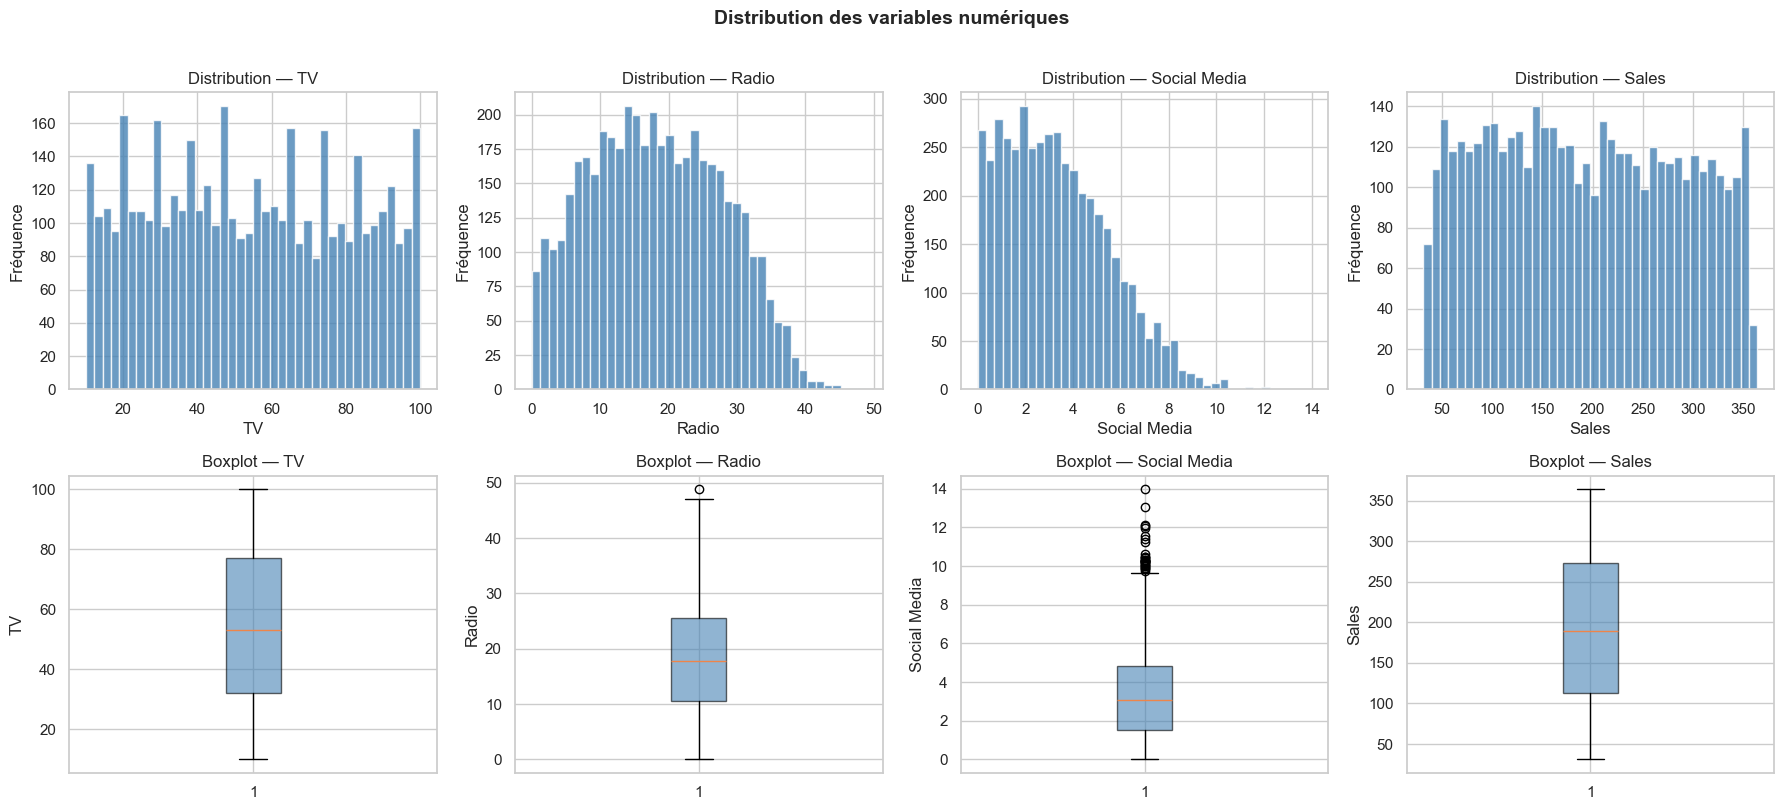

In [28]:
num_cols = ['TV', 'Radio', 'Social Media', 'Sales']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Histogramme
    axes[0, i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'Distribution — {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Fréquence')

    # Boxplot
    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, i].set_title(f'Boxplot — {col}')
    axes[1, i].set_ylabel(col)

plt.suptitle('Distribution des variables numériques', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(root_dir / 'images' / 'eda_distributions.png', bbox_inches='tight')
plt.show()

In [29]:
# Skewness & Kurtosis
print('=== Skewness & Kurtosis ===')
for col in num_cols:
    skew = df[col].skew()
    kurt = df[col].kurt()
    print(f'{col:15s} | Skewness: {skew:+.3f} | Kurtosis: {kurt:+.3f}')

=== Skewness & Kurtosis ===
TV              | Skewness: +0.069 | Kurtosis: -1.187
Radio           | Skewness: +0.143 | Kurtosis: -0.819
Social Media    | Skewness: +0.645 | Kurtosis: +0.045
Sales           | Skewness: +0.070 | Kurtosis: -1.187


## 4. Analyse de la variable cible : Sales

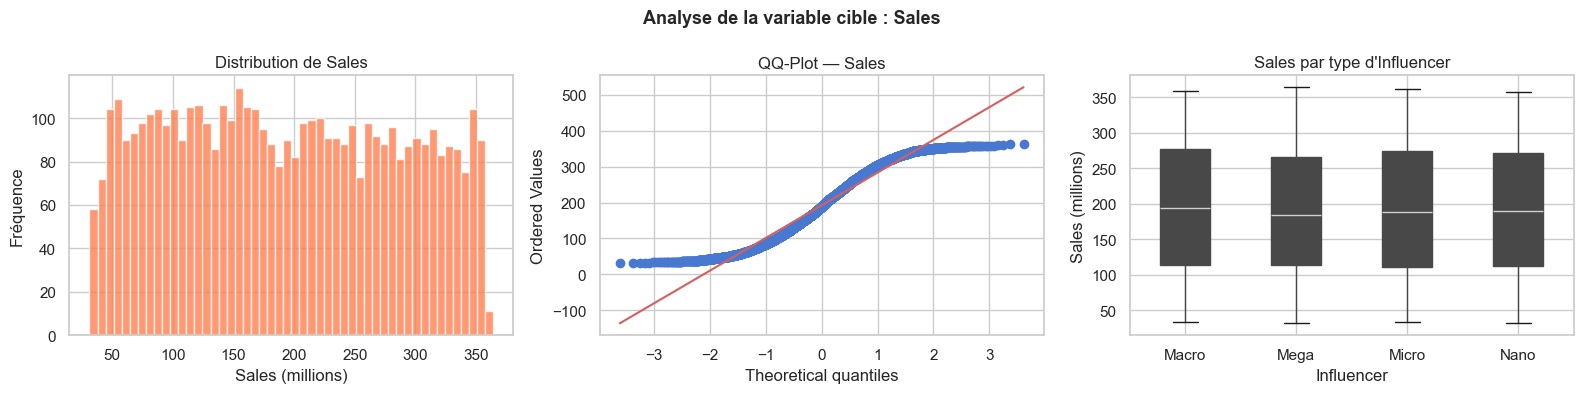


Sales — Moyenne : 192.47M | Médiane : 189.23M
Min : 31.20M | Max : 364.08M


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogramme Sales
axes[0].hist(df['Sales'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution de Sales')
axes[0].set_xlabel('Sales (millions)')
axes[0].set_ylabel('Fréquence')

# QQ-plot (normalité)
stats.probplot(df['Sales'].dropna(), dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot — Sales')

# Sales par type d'Influencer
df.boxplot(column='Sales', by='Influencer', ax=axes[2],
           patch_artist=True)
axes[2].set_title('Sales par type d\'Influencer')
axes[2].set_xlabel('Influencer')
axes[2].set_ylabel('Sales (millions)')
plt.suptitle('')

plt.suptitle('Analyse de la variable cible : Sales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir / 'images' / 'eda_sales.png', bbox_inches='tight')
plt.show()

print(f"\nSales — Moyenne : {df['Sales'].mean():.2f}M | Médiane : {df['Sales'].median():.2f}M")
print(f"Min : {df['Sales'].min():.2f}M | Max : {df['Sales'].max():.2f}M")

## 5. Relations entre budgets et Sales (scatter plots)

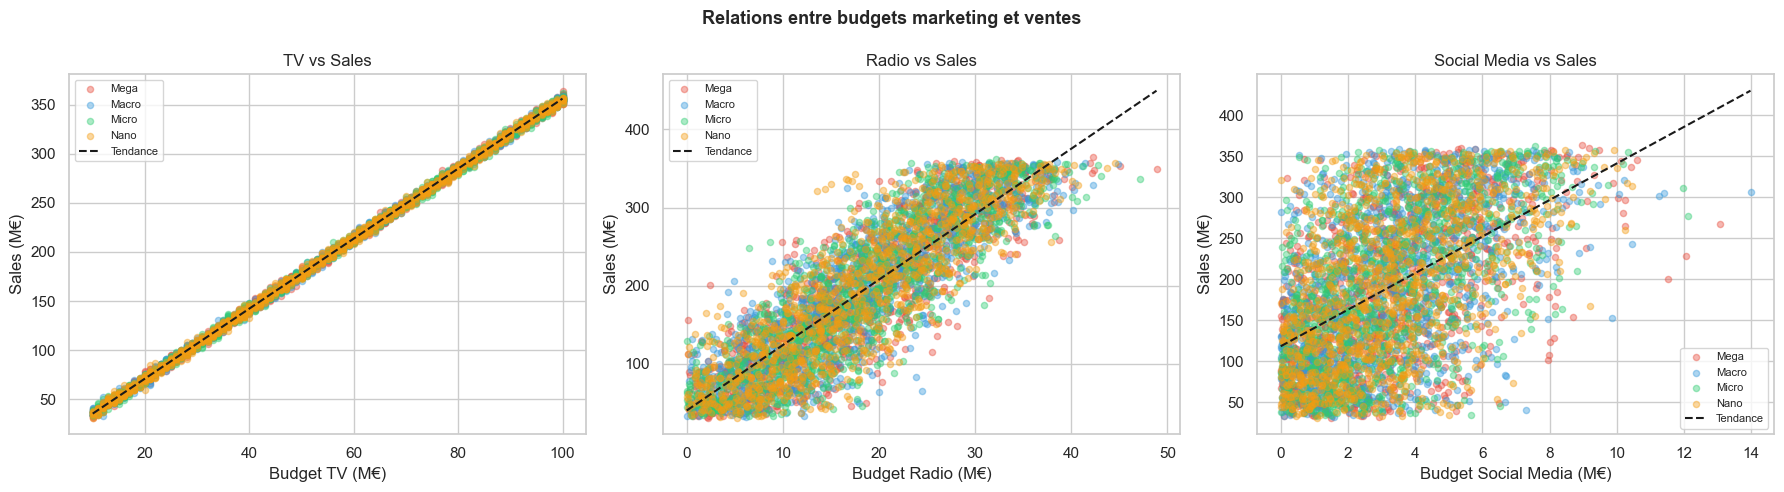

In [39]:
budget_cols = ['TV', 'Radio', 'Social Media']
colors_inf = {'Mega': '#e74c3c', 'Macro': '#3498db', 'Micro': '#2ecc71', 'Nano': '#f39c12'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(budget_cols):
    for inf_type, color in colors_inf.items():
        mask = df['Influencer'] == inf_type
        axes[i].scatter(df.loc[mask, col], df.loc[mask, 'Sales'],
                        alpha=0.4, s=20, color=color, label=inf_type)
    
    # Ligne de tendance globale
    #z = np.polyfit(df[col].dropna(), df['Sales'].dropna(), 1)
    valid = df[[col, 'Sales']].dropna()
    z = np.polyfit(valid[col], valid['Sales'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'k--', linewidth=1.5, label='Tendance')
    
    axes[i].set_xlabel(f'Budget {col} (M€)')
    axes[i].set_ylabel('Sales (M€)')
    axes[i].set_title(f'{col} vs Sales')
    axes[i].legend(fontsize=8)

plt.suptitle('Relations entre budgets marketing et ventes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir / 'images' / 'eda_scatter.png', bbox_inches='tight')
plt.show()

## 6. Matrice de corrélation

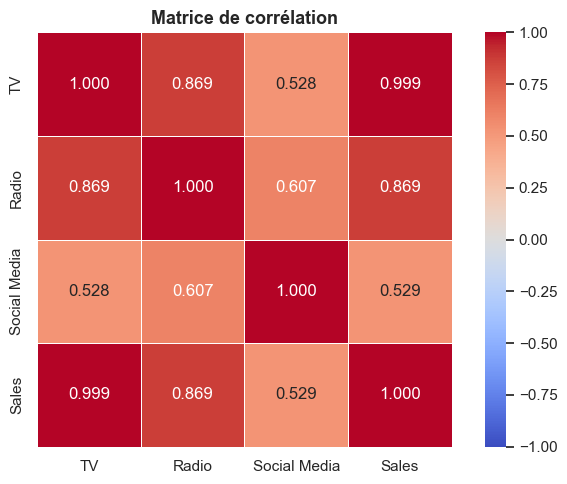


=== Corrélations avec Sales ===
Sales           1.000000
TV              0.999497
Radio           0.869105
Social Media    0.528906
Name: Sales, dtype: float64


In [32]:
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir / 'images' / 'eda_correlation.png', bbox_inches='tight')
plt.show()

print('\n=== Corrélations avec Sales ===')
print(corr_matrix['Sales'].sort_values(ascending=False))

## 7. Analyse par type d'Influencer

In [33]:
inf_stats = df.groupby('Influencer')[['TV', 'Radio', 'Social Media', 'Sales']].agg(['mean', 'median']).round(2)
print('=== Statistiques par type d\'Influencer ===')
print(inf_stats)

=== Statistiques par type d'Influencer ===
               TV         Radio        Social Media          Sales        
             mean median   mean median         mean median    mean  median
Influencer                                                                
Macro       55.05   54.0  18.32  18.01         3.37   3.12  195.61  194.23
Mega        53.50   52.0  18.08  17.69         3.37   3.16  190.59  184.17
Micro       53.85   53.0  18.23  17.97         3.27   2.94  191.81  187.95
Nano        53.90   53.5  18.02  17.59         3.28   2.96  191.93  189.66


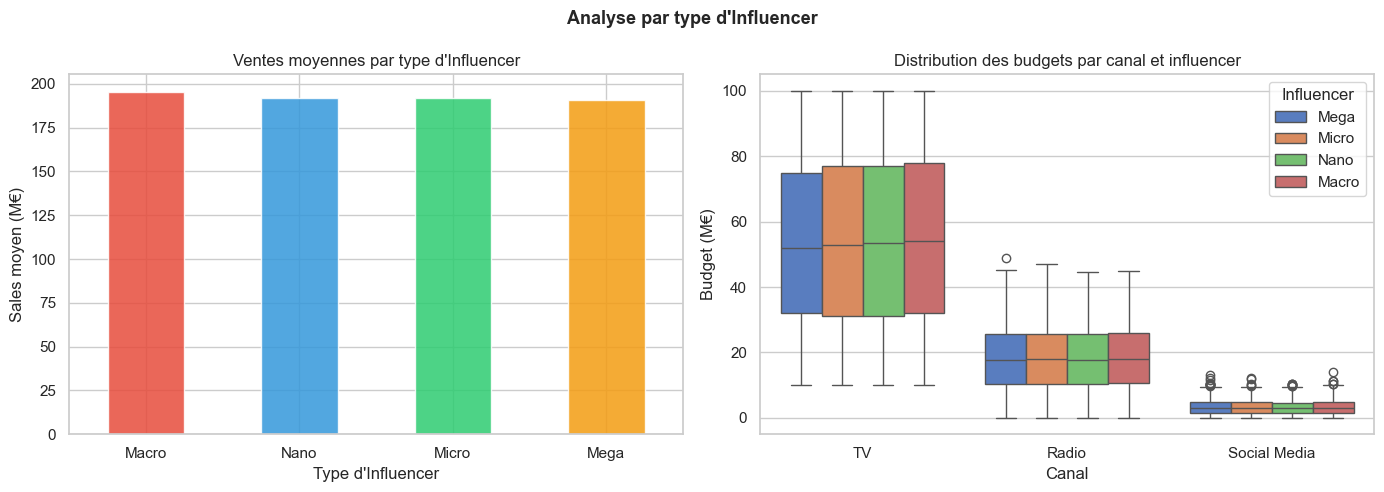

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ventes moyennes par influencer
inf_sales = df.groupby('Influencer')['Sales'].mean().sort_values(ascending=False)
inf_sales.plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db','#2ecc71','#f39c12'],
               edgecolor='white', alpha=0.85)
axes[0].set_title('Ventes moyennes par type d\'Influencer')
axes[0].set_xlabel('Type d\'Influencer')
axes[0].set_ylabel('Sales moyen (M€)')
axes[0].tick_params(axis='x', rotation=0)

# Distribution des budgets par influencer
df_melt = df.melt(id_vars=['Influencer'], value_vars=['TV', 'Radio', 'Social Media'],
                  var_name='Canal', value_name='Budget')
sns.boxplot(data=df_melt, x='Canal', y='Budget', hue='Influencer', ax=axes[1])
axes[1].set_title('Distribution des budgets par canal et influencer')
axes[1].set_ylabel('Budget (M€)')

plt.suptitle('Analyse par type d\'Influencer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir / 'images' / 'eda_influencer.png', bbox_inches='tight')
plt.show()

## 8. Détection des outliers (méthode IQR)

In [35]:
print('=== Outliers par variable (méthode IQR) ===')
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = round(n_outliers / len(df) * 100, 2)
    outlier_summary[col] = {'n_outliers': n_outliers, 'pct': pct, 'lower': round(lower,2), 'upper': round(upper,2)}
    print(f'{col:15s} | Outliers: {n_outliers:4d} ({pct}%) | Seuils: [{lower:.2f}, {upper:.2f}]')

=== Outliers par variable (méthode IQR) ===
TV              | Outliers:    0 (0.0%) | Seuils: [-35.50, 144.50]
Radio           | Outliers:    1 (0.02%) | Seuils: [-12.16, 48.34]
Social Media    | Outliers:   28 (0.61%) | Seuils: [-3.39, 9.73]
Sales           | Outliers:    0 (0.0%) | Seuils: [-127.95, 512.79]


## 9. Analyse spécifique à notre problématique — Impact Marginal

In [36]:
# Calcul du ROI brut et du budget total pour avoir une idée de l'efficacité
df['Total_Budget'] = df['TV'] + df['Radio'] + df['Social Media']
df['ROI'] = df['Sales'] / df['Total_Budget']
df['TV_share'] = df['TV'] / df['Total_Budget']
df['Radio_share'] = df['Radio'] / df['Total_Budget']
df['Social_share'] = df['Social Media'] / df['Total_Budget']

print('=== ROI par type d\'Influencer ===')
print(df.groupby('Influencer')['ROI'].agg(['mean','median','std']).round(3))

=== ROI par type d'Influencer ===
             mean  median    std
Influencer                      
Macro       2.550   2.559  0.284
Mega        2.543   2.553  0.275
Micro       2.547   2.553  0.280
Nano        2.550   2.541  0.288


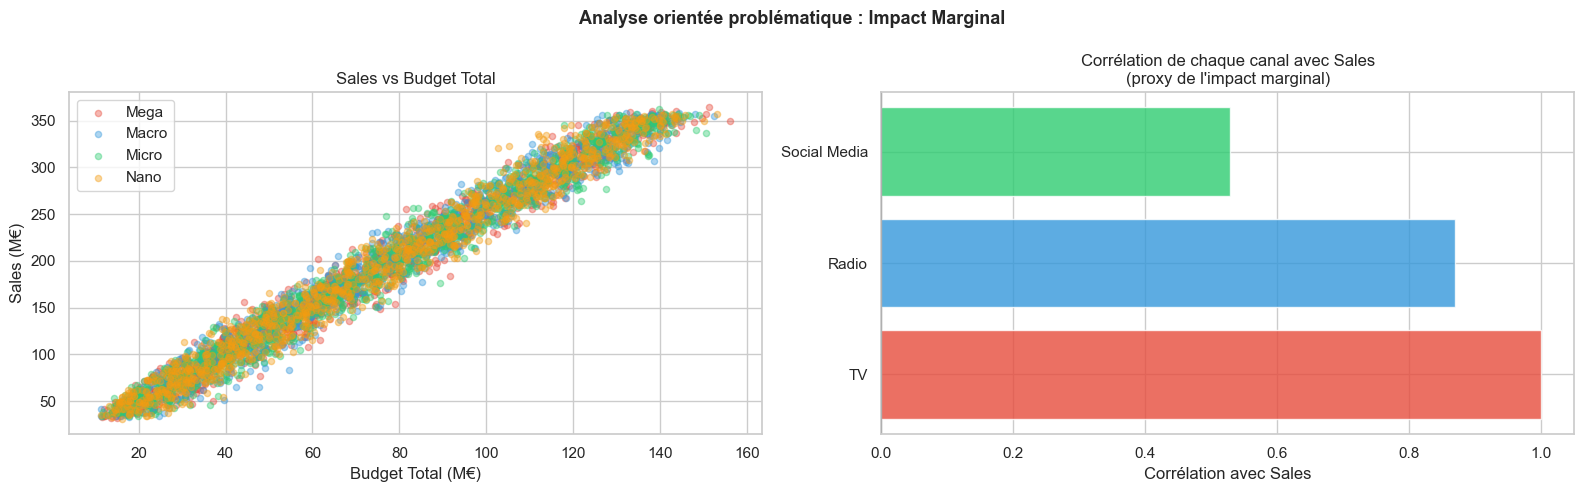

In [37]:
# Visualisation : Sales vs Budget Total coloré par Influencer
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sales vs Budget Total
for inf_type, color in colors_inf.items():
    mask = df['Influencer'] == inf_type
    axes[0].scatter(df.loc[mask, 'Total_Budget'], df.loc[mask, 'Sales'],
                    alpha=0.4, s=20, color=color, label=inf_type)
axes[0].set_xlabel('Budget Total (M€)')
axes[0].set_ylabel('Sales (M€)')
axes[0].set_title('Sales vs Budget Total')
axes[0].legend()

# ROI moyen par canal (part de budget)
canal_roi = pd.DataFrame({
    'Canal': ['TV', 'Radio', 'Social Media'],
    'Corrélation avec Sales': [
        df['TV'].corr(df['Sales']),
        df['Radio'].corr(df['Sales']),
        df['Social Media'].corr(df['Sales'])
    ]
})
axes[1].barh(canal_roi['Canal'], canal_roi['Corrélation avec Sales'],
             color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8)
axes[1].set_xlabel('Corrélation avec Sales')
axes[1].set_title('Corrélation de chaque canal avec Sales\n(proxy de l\'impact marginal)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('Analyse orientée problématique : Impact Marginal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir / 'images' / 'eda_marginal.png', bbox_inches='tight')
plt.show()

## 10. Synthèse EDA — Conclusions

In [38]:
print('=' * 55)
print('SYNTHÈSE EDA')
print('=' * 55)
print(f"Dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"Doublons : {df.duplicated().sum()}")
print()
print('--- Variable cible (Sales) ---')
print(f"  Moyenne  : {df['Sales'].mean():.2f} M€")
print(f"  Médiane  : {df['Sales'].median():.2f} M€")
print(f"  Std      : {df['Sales'].std():.2f} M€")
print(f"  Min/Max  : {df['Sales'].min():.2f} / {df['Sales'].max():.2f} M€")
print()
print('--- Corrélations avec Sales ---')
for col in ['TV', 'Radio', 'Social Media']:
    r = df[col].corr(df['Sales'])
    print(f"  {col:15s} : r = {r:.4f}")
print()
print('--- Distribution Influencer ---')
print(df['Influencer'].value_counts().to_string())
print()
print('Points clés pour la modélisation :')
print('  - Identifier le canal avec la corrélation la plus forte → impact marginal élevé')
print('  - Encoder Influencer (OneHot ou Ordinal)')
print('  - Vérifier si normalisation nécessaire (MLP)')
print('  - Attention aux outliers sur TV et Sales')

SYNTHÈSE EDA
Dataset : 4572 lignes, 10 colonnes
Valeurs manquantes : 132
Doublons : 0

--- Variable cible (Sales) ---
  Moyenne  : 192.47 M€
  Médiane  : 189.23 M€
  Std      : 93.13 M€
  Min/Max  : 31.20 / 364.08 M€

--- Corrélations avec Sales ---
  TV              : r = 0.9995
  Radio           : r = 0.8691
  Social Media    : r = 0.5289

--- Distribution Influencer ---
Influencer
Mega     1158
Micro    1153
Nano     1139
Macro    1122

Points clés pour la modélisation :
  - Identifier le canal avec la corrélation la plus forte → impact marginal élevé
  - Encoder Influencer (OneHot ou Ordinal)
  - Vérifier si normalisation nécessaire (MLP)
  - Attention aux outliers sur TV et Sales
